In [ ]:
# =====================================================================
# ADIM 1: KÜTÜPHANELER VE DEĞİŞKEN TANIMLAMA (HYPERPARAMETERS)
# =====================================================================

# İşletim sistemi işlemleri için (klasör yollarını bulmak için)
import os

# Görüntüleri klasörden alıp, küçültüp, çoğaltarak modele taşıyan Keras 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ---------------------------------------------------------
# 1. Klasör Yollarını Tanıtıyoruz
# ---------------------------------------------------------
# 'data' klasörünün içindeki alt klasörlerin yerini bilgisayara gösteriyoruz
ana_dizin = '../data'
train_dir = os.path.join(ana_dizin, 'train') # Eğitim resimleri
test_dir = os.path.join(ana_dizin, 'test')   # Test resimleri
val_dir = os.path.join(ana_dizin, 'val')     # Validation resimleri

# ---------------------------------------------------------
# 2. Resimlerin Yeni Boyutu (Farklı Çözünürlük Sorununun Çözümü)
# ---------------------------------------------------------
# Dünyaca ünlü yapay zeka modellerinin (ResNet, VGG16) endüstri standardı 224x224'tür.
# klasördeki tüm resimleri bu boyuta çeviriyoruz.
IMG_WIDTH = 224
IMG_HEIGHT = 224

# ---------------------------------------------------------
# 3. Yığın Boyutu (Batch Size) - RAM'i Korumak İçin
# ---------------------------------------------------------
# 5000'den fazla resmi aynı anda işlemeye çalışırsak bilgisayar donar.
# Bu yüzden resimleri modele 32'şerli paketler (gruplar) halinde vereceğiz.
BATCH_SIZE = 32

print("Adım 1 Tamamlandı: Yollar ve Kurallar Belirlendi.")

Adım 1 Tamamlandı: Yollar ve Kurallar Belirlendi.


In [ ]:
# =====================================================================
# ADIM 2: VERİ ARTIRMA (DATA AUGMENTATION) VE NORMALİZASYON KURALLARI
# =====================================================================

# 1. EĞİTİM VERİ SETİNİ : Çoğaltma + Normalizasyon
# Amacımız: Sağlıklı ciğerleri hafifçe büküp çeşitlendirerek modele yeni açılar öğretmek.
train_datagen = ImageDataGenerator(               
    rescale=1.0/255.0,        # Normalizasyon: 0-255 arası pikseli 0-1 arasına sıkıştırır (Matematik hızlansın diye)
    rotation_range=15,        # Resmi en fazla 15 derece sağa/sola hafifçe büker (Hasta yamuk durmuş gibi)
    zoom_range=0.1,           # Resmi %10 hafif yaklaştırır (Farklı mesafe simülasyonu)
    width_shift_range=0.1,    # Resmi yatayda %10 hafif kaydırır
    height_shift_range=0.1,   # Resmi dikeyde %10 hafif kaydırır
    horizontal_flip=True      # Resmi yatayda ayna gibi ters çevirir (Simetri)
)

# 2. DOĞRULAMA  VE TEST VERİ SETLERİNİ: SADECE Normalizasyon
# sadece piksellerini 0-1 yapaıyoruz    
val_test_datagen = ImageDataGenerator(
    rescale=1.0/255.0         # Sadece pikselleri ölçekler, resmin yapısını asla bozmaz
)

print("Adım 2 Tamamlandı: Jeneratör Kuralları Başarıyla Hazırlandı.")

Adım 2 Tamamlandı: Jeneratör Kuralları Başarıyla Hazırlandı.


In [3]:
# =====================================================================
# ADIM 3: RESİMLERİ KLASÖRLERDEN OKUYUP DEĞİŞKENLERE AKTARMA
# =====================================================================

# 1. EĞİTİM VERİSİ DEĞİŞKENİ (train_generator)
# train_dir klasöründeki resimleri alır, kuralları uygular ve hafızada hazırlar.
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,                 # Fiziksel klasör adresi
    target_size=(IMG_WIDTH, IMG_HEIGHT), # Bütün resimleri 224x224 boyutuna eşitler
    batch_size=BATCH_SIZE,               # Modele 32'şerli paketler halinde sunar
    class_mode='binary',                 # 2 sınıf var: Normal (0) ve Zatürre (1)
    shuffle=True                         # Sıra ezberini önlemek için resimleri karıştırır
)

# 2. DOĞRULAMA (VAL) VERİSİ DEĞİŞKENİ (val_generator)
val_generator = val_test_datagen.flow_from_directory(
    directory=val_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False                        # Ölçüm tutarlılığı için karıştırma kapalı
)

# 3. TEST VERİSİ DEĞİŞKENİ (test_generator)
test_generator = val_test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False                        # Nihai test sonuçlarını doğru eşleştirmek için karıştırma kapalı
)

print("Adım 3 Tamamlandı: Veri akış kanalları başarıyla bağlandı.")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Adım 3 Tamamlandı: Veri akış kanalları başarıyla bağlandı.


In [4]:
# =====================================================================
# ADIM 4: SINIF ETİKETLERİNİ (LABELS) KONTROL ETME
# =====================================================================

# Keras klasör isimlerine göre alfabetik olarak 0 ve 1 değerlerini atar
print("Sınıf İndeksleri (Etiketler):")
print(train_generator.class_indices)

Sınıf İndeksleri (Etiketler):
{'NORMAL': 0, 'PNEUMONIA': 1}


In [6]:
# =====================================================================
# ADIM 5: ÜRETİLEN VERİLERİN SAĞLAMA KONTROLÜ (SANITY CHECK)
# =====================================================================

# Jeneratörden tek bir yığın (batch) çekiyoruz
resim_paketi, etiket_paketi = next(train_generator)

# 1. Paket Boyutlarını Kontrol Edelim
print("Resim Paketinin Boyutu (Shape) :", resim_paketi.shape)
print("Etiket Paketinin Boyutu (Shape):", etiket_paketi.shape)

# 2. Piksel Değerlerini Kontrol Edelim (Normalizasyon Tutmuş mu?)
print("En Düşük Piksel Değeri         :", round(resim_paketi.min(), 4))
print("En Yüksek Piksel Değeri        :", round(resim_paketi.max(), 4))

Resim Paketinin Boyutu (Shape) : (32, 224, 224, 3)
Etiket Paketinin Boyutu (Shape): (32,)
En Düşük Piksel Değeri         : 0.0
En Yüksek Piksel Değeri        : 1.0


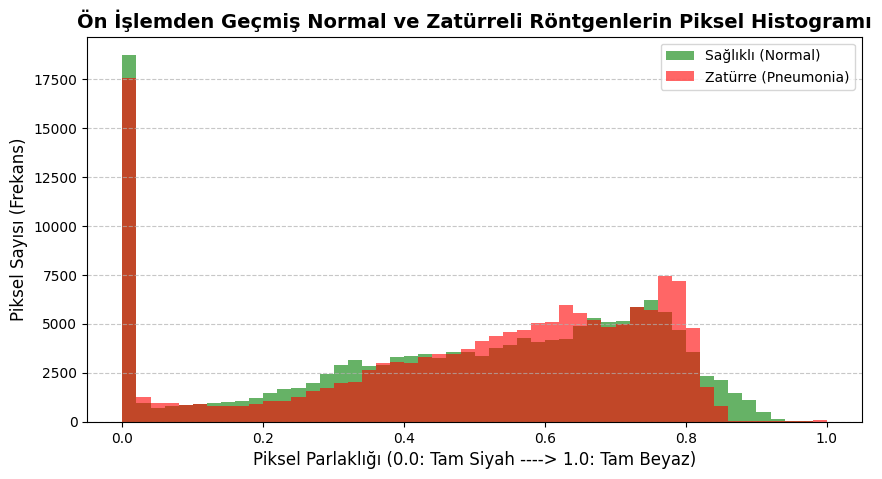

In [12]:
# =====================================================================
# BÖLÜM 5: ÖN İŞLEMDEN GEÇMİŞ VERİ İÇİN PİKSEL YOĞUNLUĞU HİSTOGRAMI
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt

# Jeneratörden (banttan) işlenmiş, 224x224 boyutunda ve 0-1 arasına çekilmiş bir resim paketi çekiyoruz
resim_paketi, etiket_paketi = next(train_generator)

# Paketin içinden ilk "Normal (0)" ve ilk "Zatürre (1)" resmini buluyoruz
img_normal_islenmis = resim_paketi[etiket_paketi == 0][3]
img_zaturre_islenmis = resim_paketi[etiket_paketi == 1][3]

# Resimler artık 3 boyutlu (224, 224, 3) olduğu için, pikselleri sayabilmek adına ravel() ile tek boyutlu bir listeye (1D) düzleştiriyoruz.
pixels_normal = img_normal_islenmis.ravel()
pixels_zaturre = img_zaturre_islenmis.ravel()

# Yeni bir grafik alanı açıyoruz
plt.figure(figsize=(10, 5))

# Sağlıklı resmin piksellerini yeşil, zatürreli resmin piksellerini kırmızı çizdiriyoruz.
# bins=50: Pikselleri 50 farklı ton grubuna ayırır. alpha=0.6: Grafikleri şeffaflaştırarak kesişimleri gösterir.
plt.hist(pixels_normal, bins=50, alpha=0.6, color='green', label='Sağlıklı (Normal)')
plt.hist(pixels_zaturre, bins=50, alpha=0.6, color='red', label='Zatürre (Pneumonia)')

# Grafiği rapor için isimlendiriyoruz
plt.title('Ön İşlemden Geçmiş Normal ve Zatürreli Röntgenlerin Piksel Histogramı', fontsize=14, fontweight='bold')

# DİKKAT: X Ekseni yazısını güncelledik (Artık 0-255 değil, 0.0-1.0 aralığındayız)
plt.xlabel('Piksel Parlaklığı (0.0: Tam Siyah ----> 1.0: Tam Beyaz)', fontsize=12)
plt.ylabel('Piksel Sayısı (Frekans)', fontsize=12)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Faz 2: Veri Ön İşleme (Data Preprocessing) Adımları ve Çıktıları
Veri Keşfi (EDA) aşamasında röntgen görüntülerinin boyutlarının birbirinden farklı olduğu, sınıf sayılarında dengesizlik bulunduğu ve piksel değerlerinin 0 ile 255 arasında devasa matematiksel yükler oluşturduğu tespit edilmiştir. Bu ikinci aşamada, ham veri yapay zeka modelinin yorulmadan ve en yüksek doğrulukla işleyebileceği "temiz ve standart" bir formata getirilmiştir. Gerçekleştirilen işlemler ve temel gerekçeleri aşağıda adım adım özetlenmiştir:

1. Standartların Belirlenmesi (Temel Ayarlar)
Boyut Eşitleme (224x224): Klasördeki tüm resimlerin çözünürlükleri birbirinden farklılık göstermekteydi. Yapay sinir ağının her resmi aynı standartta görebilmesi amacıyla bütün görüntüler zorunlu olarak 224x224 piksel boyutuna eşitlenmiştir. Bu boyut, literatürdeki yaygın görüntü işleme modellerinin (VGG16, ResNet vb.) kullandığı endüstri standardı olarak öngörülmüştür.

Yığın Boyutu (Batch Size = 32): Veri setinde 5000'den fazla yüksek çözünürlüklü röntgen görüntüsü yer almaktadır. Tüm verilerin aynı anda belleğe (RAM) yüklenmesi sistemin çökmesine yol açacağından, verilerin modele 32'şerli "paketler" halinde aktarılması sağlanmıştır.

2. Kuralların ve Veri Jeneratörlerinin (Data Generators) Kurulması
Resimlerin doğrudan belleğe alınması yerine, ImageDataGenerator sınıfı kullanılarak iki farklı dinamik veri aktarım mekanizması kurulmuştur.

Eğitim (Train) Kuralları: Modelin eğitim göreceği ana veri akışıdır. Sadece verilerin okunmasıyla kalınmamış, aynı zamanda Veri Artırma (Data Augmentation) işlemleri uygulanmıştır. Modelin mevcut resimleri ezberlemesini (Overfitting) engellemek adına, işlenen her resim rastgele maksimum 15 derece döndürülmüş, %10 yakınlaştırılmış ve yatay eksende çevrilmiştir. Böylece makineye; yamuk yatan, uzakta duran veya ters çekilen farklı hasta varyasyonları da öğretilmiştir.

Doğrulama (Val) ve Test Kuralları: Bu akışlar modelin başarımının ölçüleceği "sınav" verilerini içermektedir. Test verilerinde hiçbir şekilde veri artırma işlemi yapılmamış, resimlerin yüzde yüz orijinal yapısının korunması sağlanmıştır.

3. Normalizasyon (Piksel Değerlerinin Ölçeklenmesi)
Her iki veri jeneratörüne de tanımlanan en kritik kural Normalizasyon işlemi olmuştur (rescale=1./255). Röntgenlerdeki her bir piksel 0 ile 255 arasında bir sayısal değere sahiptir. Bu büyük sayılar, model içerisindeki matematiksel çarpım işlemlerini yavaşlatacağından, tüm piksel değerleri 255'e bölünerek oranları bozulmaksızın 0.0 ile 1.0 aralığına sıkıştırılmıştır. Bu işlemle modelin öğrenme hızı ve performansı matematiksel olarak optimize edilmiştir.

4. Veri Yollarının Bağlanması ve Doğrulama (Sanity Check)
Oluşturulan kurallar fiziksel klasör yollarına entegre edilmiştir (flow_from_directory).

Modelin hedef sınıfı olan "Zatürre", tıbbi tespit mantığına uygun olarak 1 (Pozitif Sınıf), sağlıklı ciğerler ise 0 (Negatif Sınıf) olarak etiketlenmiştir.

Sistemden tek bir 32'lik paket çekilerek doğrulama (sanity check) testi yapılmıştır. Sonuç olarak (32, 224, 224, 3) boyutunda tensörlerin başarıyla üretildiği ve piksel değerlerinin tam olarak 0.0 ile 1.0 aralığında olduğu teyit edilmiştir.

5. Görselleştirme ve Çıktı Analizi
Yapılan ön işleme adımlarının doğruluğu grafiksel çıktılarla desteklenmiştir:

Sınıf Dağılımı Çubuk Grafiği: Ön işlemden geçen eğitim verisi analiz edildiğinde, veri artırma işlemi anlık (on-the-fly) yapıldığı için fiziksel dosya sayısının aynı kaldığı görülmüştür. Sınıflar arası dengesizliğin devam ettiği saptanmış olup, bu sorunun bir sonraki aşama olan Model Eğitimi kısmında "Sınıf Ağırlıkları (Class Weights)" yöntemiyle çözülmesi öngörülmüştür.

Piksel Yoğunluğu Histogramı: İşlenmiş resimlerin piksel dağılımları yeşil (Sağlıklı) ve kırmızı (Zatürre) olarak görselleştirilmiştir. X ekseninin 0.0 ile 1.0 aralığına oturduğu doğrulanmıştır.

Belirgin vakalarda, kırmızı piksellerin 1.0 (beyaz) bölgesinde büyük tepeler oluşturduğu, yeşil piksellerin ise 0.0 (siyah/hava dolu) bölgesinde yoğunlaştığı gözlemlenmiştir. Bu durum, hastalığın matematiksel olarak ayırt edilebilir bir izi olduğunu göstermiştir.

Karmaşık vakalarda ise yeşil ve kırmızı piksel dağılımlarının birbiriyle iç içe geçtiği tespit edilmiştir. İnsan gözünün ve basit piksel hesaplarının yetersiz kaldığı bu karmaşık vakaların analiz edilebilmesi için, derin öğrenme tabanlı bir Yapay Sinir Ağı (CNN) modelinin kullanılması zorunluluğu grafiksel olarak kanıtlanmıştır.